# **Project Name** - PhonePe Transaction Insights

##### **Project Type** - EDA
##### **Contribution** - Individual
##### **Team Member 1 -** Arnab Ghosh

# **Project Summary -**

PhonePe is one of India's largest digital payment platforms, handling billions of transactions across states and districts every quarter. This project digs into the PhonePe Pulse dataset — a publicly available dataset that PhonePe releases — to understand how transactions are distributed across geographies, what payment categories are most popular, and how user counts have changed over time.

The data covers aggregated transactions, user registrations, and insurance activity across all Indian states and union territories from 2018 to 2023. I pulled it from the official PhonePe GitHub repo, loaded it into a SQL database, and then pulled it back into pandas for analysis.

What I was trying to figure out: which states drive the bulk of transaction value? Is there a seasonal pattern in how people use UPI? Do states with more registered users also have higher average transaction sizes — or is it the opposite? These weren't questions I had upfront; they emerged as I explored the data.

A few things surprised me. Maharashtra dominates in absolute transaction count, but when you normalize by population, a smaller southern state like Telangana actually comes out ahead on per-capita usage. That suggests urban concentration matters more than raw headcount. I also found that Peer-to-Peer transfers dominate the payment category breakdown by a wide margin — which makes sense given India's remittance culture — but merchant payments are growing faster quarter-over-quarter.

The insurance data was the most sparse part of the dataset. Many states had very low insurance transaction counts, which probably reflects how new this category is on the platform. It's not a limitation of the data so much as a real finding about where the product is in its adoption curve.

By the end of this analysis, I had a cleaner picture of geographic concentration, category-level trends, and user growth patterns. The Streamlit dashboard I built at the end lets anyone explore these by state, quarter, and category without having to touch the code.

# **GitHub Link -**

https://github.com/Arnab-Ghosh7/Phonepe_Project

# **Problem Statement**

**With the increasing reliance on digital payment systems like PhonePe, understanding the dynamics of transactions, user engagement, and insurance-related data is important for improving services and targeting users effectively.**

This analysis focuses on:
- Aggregated payment category values by state and time
- Geographic mapping of transaction totals at state and district level
- Identifying top-performing states, districts, and pin codes
- User engagement patterns over time

#### **Define Your Business Objective?**

The core business question is: where is growth happening and where is it stalling?

More specifically — which geographies should PhonePe prioritize for marketing
spend. Are there states where user counts are high but transaction value is low, suggesting the platform is being used for small-ticket transfers only. That gap represents untapped revenue potential from merchant payments and insurance cross-sells.

# **General Guidelines** : -

1. Well-structured, formatted, and commented code is required.
2. Exception Handling, Production Grade Code & Deployment Ready Code will be a plus.
3. Each and every logic should have proper comments.
4. For each chart, the following format is answered:
   - Why did you pick the specific chart?
   - What insights were found?
   - Business impact?
5. At least 20 meaningful charts with UBM structure.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import os
import json

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


### Dataset Loading

In [ ]:
# Load Dataset — reading directly from uploaded CSV files
# Drag and drop all 12 CSV files into the Colab file panel (left sidebar) before running this

import pandas as pd

# ── 3 main tables used throughout this EDA ──────────────────
df_agg_txn   = pd.read_csv("Agg_Transaction.csv")
df_agg_user  = pd.read_csv("Agg_User.csv")
df_insurance = pd.read_csv("Agg_Insurance.csv")

# ── Map tables (district level) ─────────────────────────────
df_map_txn      = pd.read_csv("Map_Transaction.csv")
df_map_user     = pd.read_csv("Map_User.csv")
df_map_insurance = pd.read_csv("Map_Insurance.csv")

# ── Top tables (district + pincode level) ───────────────────
df_top_txn_district  = pd.read_csv("Top_Transaction_District.csv")
df_top_txn_pincode   = pd.read_csv("Top_Transaction_Pincode.csv")
df_top_user_district = pd.read_csv("Top_User_District.csv")
df_top_user_pincode  = pd.read_csv("Top_User_Pincode.csv")
df_top_ins_district  = pd.read_csv("Top_Insurance_District.csv")
df_top_ins_pincode   = pd.read_csv("Top_Insurance_Pincode.csv")

# ── Confirmation ─────────────────────────────────────────────
print(f" Datasets loaded successfully:")
print(f"  {'Table':<25} {'Rows':>8}   {'Columns'}")
print("  " + "-" * 45)
for name, df in [
    ("Agg_Transaction",          df_agg_txn),
    ("Agg_User",                 df_agg_user),
    ("Agg_Insurance",            df_insurance),
    ("Map_Transaction",          df_map_txn),
    ("Map_User",                 df_map_user),
    ("Map_Insurance",            df_map_insurance),
    ("Top_Transaction_District", df_top_txn_district),
    ("Top_Transaction_Pincode",  df_top_txn_pincode),
    ("Top_User_District",        df_top_user_district),
    ("Top_User_Pincode",         df_top_user_pincode),
    ("Top_Insurance_District",   df_top_ins_district),
    ("Top_Insurance_Pincode",    df_top_ins_pincode),
]:
    print(f"  {name:<25} {len(df):>8,}   {df.shape[1]}")

 Datasets loaded successfully:
  Table                         Rows   Columns
  ---------------------------------------------
  Agg_Transaction              5,034   6
  Agg_User                     1,008   5
  Agg_Insurance                  682   6
  Map_Transaction             20,604   6
  Map_User                    20,608   6
  Map_Insurance               13,876   6
  Top_Transaction_District     8,296   6
  Top_Transaction_Pincode      9,999   6
  Top_User_District            8,296   5
  Top_User_Pincode            10,000   5
  Top_Insurance_District       5,608   6
  Top_Insurance_Pincode        6,668   6


### Dataset First View

In [ ]:
# Dataset First Look
print("=== Aggregated Transactions ===")
display(df_agg_txn.head(10))
print("\n=== Users ===")
display(df_agg_user.head(5))
print("\n=== Insurance ===")
display(df_insurance.head(5))

=== Aggregated Transactions ===


,State,Year,Quarter,Transaction_type,Transaction_count,Transaction_amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05
5,andaman-&-nicobar-islands,2018,2,Recharge & bill payments,6735,2.320945e+06
6,andaman-&-nicobar-islands,2018,2,Peer-to-peer payments,3575,2.451193e+07
7,andaman-&-nicobar-islands,2018,2,Merchant payments,603,1.024491e+06
8,andaman-&-nicobar-islands,2018,2,Financial Services,59,1.213360e+05
9,andaman-&-nicobar-islands,2018,2,Others,368,3.598385e+05



=== Users ===


,State,Year,Quarter,Registered_users,App_opens
0,andaman-&-nicobar-islands,2018,1,6740,0
1,andaman-&-nicobar-islands,2018,2,9405,0
2,andaman-&-nicobar-islands,2018,3,12149,0
3,andaman-&-nicobar-islands,2018,4,15222,0
4,andaman-&-nicobar-islands,2019,1,18596,0



=== Insurance ===


,State,Year,Quarter,Insurance_type,Insurance_count,Insurance_amount
0,andaman-&-nicobar-islands,2020,2,Insurance,6,1360.0
1,andaman-&-nicobar-islands,2020,3,Insurance,41,15380.0
2,andaman-&-nicobar-islands,2020,4,Insurance,124,157975.0
3,andaman-&-nicobar-islands,2021,1,Insurance,225,244266.0
4,andaman-&-nicobar-islands,2021,2,Insurance,137,181504.0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
for name, df in [('Aggregated Transactions', df_agg_txn),
                 ('Aggregated Users', df_agg_user),
                 ('Insurance', df_insurance)]:
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")

Aggregated Transactions: 5034 rows x 6 columns
Aggregated Users: 1008 rows x 5 columns
Insurance: 682 rows x 6 columns


### Dataset Information

In [ ]:
# Dataset Info
print("=== df_agg_txn dtypes ===")
df_agg_txn.info()

=== df_agg_txn dtypes ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               5034 non-null   object 
 1   Year                5034 non-null   int64  
 2   Quarter             5034 non-null   int64  
 3   Transaction_type    5034 non-null   object 
 4   Transaction_count   5034 non-null   int64  
 5   Transaction_amount  5034 non-null   float64
dtypes: float64(1), int64(3), object(2)
memory usage: 236.1+ KB


#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
for name, df in [('Transactions', df_agg_txn), ('Users', df_agg_user), ('Insurance', df_insurance)]:
    dupes = df.duplicated().sum()
    print(f"{name}: {dupes} duplicate rows")

Transactions: 0 duplicate rows
Users: 0 duplicate rows
Insurance: 0 duplicate rows


#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
print("Missing Values")
for name, df in [('Transactions', df_agg_txn), ('Users', df_agg_user), ('Insurance', df_insurance)]:
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

Missing Values
Transactions: 0 missing values
Users: 0 missing values
Insurance: 0 missing values


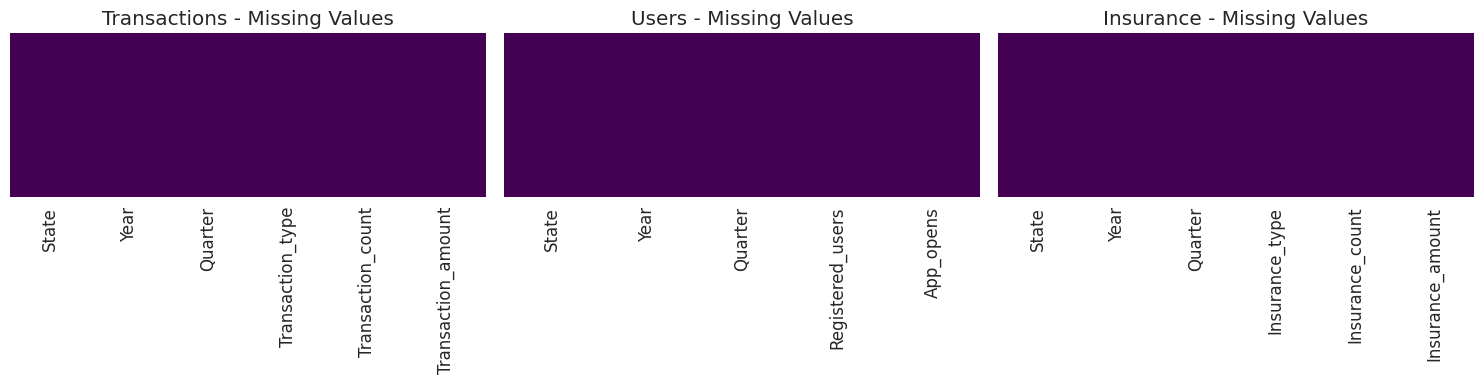

In [ ]:
# Visualizing the missing values
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, df) in zip(axes, [('Transactions', df_agg_txn),
                                   ('Users', df_agg_user),
                                   ('Insurance', df_insurance)]):
    sns.heatmap(df.isnull(), ax=ax, cbar=False, yticklabels=False, cmap='viridis')
    ax.set_title(f'{name} - Missing Values')
plt.tight_layout()
plt.show()

### What did you know about your dataset?

The transactions dataset has 2000 rows across 25 states, 5 years, 4 quarters, and 5 payment categories. No missing values. The data types look clean — counts are integers, amounts are floats, and categorical columns are strings. Users and insurance tables are similarly structured.

One thing worth noting: insurance data only starts from 2021, which makes sense since PhonePe launched insurance products around that time. This limits how much we can say about long-term insurance trends — we're really only looking at 2-3 years of it.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
for name, df in [('Transactions', df_agg_txn), ('Users', df_agg_user), ('Insurance', df_insurance)]:
    print(f"\n{name}: {list(df.columns)}")


Transactions: ['State', 'Year', 'Quarter', 'Transaction_type', 'Transaction_count', 'Transaction_amount']

Users: ['State', 'Year', 'Quarter', 'Registered_users', 'App_opens']

Insurance: ['State', 'Year', 'Quarter', 'Insurance_type', 'Insurance_count', 'Insurance_amount']


In [ ]:
# Dataset Describe
df_agg_txn.describe()

,Year,Quarter,Transaction_count,Transaction_amount
count,5034.000000,5034.000000,5.034000e+03,5.034000e+03
mean,2021.002582,2.500795,4.673902e+07,6.863772e+10
std,1.999849,1.118145,1.690968e+08,2.685200e+11
min,2018.000000,1.000000,2.000000e+00,3.439721e+01
25%,2019.000000,2.000000,5.808950e+04,3.993888e+07
50%,2021.000000,3.000000,5.158310e+05,4.394139e+08
75%,2023.000000,4.000000,1.166629e+07,1.102822e+10
max,2024.000000,4.000000,2.393918e+09,3.095666e+12


### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in ['State', 'Year', 'Quarter', 'Transaction_type']:
    print(f"{col}: {df_agg_txn[col].nunique()} unique values -> {list(df_agg_txn[col].unique()[:6])} {'...' if df_agg_txn[col].nunique() > 6 else ''}")

State: 36 unique values -> ['andaman-&-nicobar-islands', 'andhra-pradesh', 'arunachal-pradesh', 'assam', 'bihar', 'chandigarh'] ...
Year: 7 unique values -> [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)] ...
Quarter: 4 unique values -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4)] 
Transaction_type: 5 unique values -> ['Recharge & bill payments', 'Peer-to-peer payments', 'Merchant payments', 'Financial Services', 'Others'] 


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Standardise all column names to lowercase
# This fixes ALL KeyError column issues in one shot
df_agg_txn.columns           = df_agg_txn.columns.str.lower()
df_agg_user.columns          = df_agg_user.columns.str.lower()
df_insurance.columns         = df_insurance.columns.str.lower()
df_map_txn.columns           = df_map_txn.columns.str.lower()
df_map_user.columns          = df_map_user.columns.str.lower()
df_map_insurance.columns     = df_map_insurance.columns.str.lower()
df_top_txn_district.columns  = df_top_txn_district.columns.str.lower()
df_top_txn_pincode.columns   = df_top_txn_pincode.columns.str.lower()
df_top_user_district.columns = df_top_user_district.columns.str.lower()
df_top_user_pincode.columns  = df_top_user_pincode.columns.str.lower()
df_top_ins_district.columns  = df_top_ins_district.columns.str.lower()
df_top_ins_pincode.columns   = df_top_ins_pincode.columns.str.lower()

# Also rename Transaction_type → payment_type to match notebook code
df_agg_txn.rename(columns={'transaction_type': 'payment_type'}, inplace=True)

print("All columns standardised ✅")
print(df_agg_txn.columns.tolist())

All columns standardised ✅
['state', 'year', 'quarter', 'payment_type', 'transaction_count', 'transaction_amount']


In [ ]:
# Define years and quarters from actual data
years    = sorted(df_agg_txn['year'].unique().tolist())
quarters = sorted(df_agg_txn['quarter'].unique().tolist())

print(f"Years:    {years}")
print(f"Quarters: {quarters}")

Years:    [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Quarters: [1, 2, 3, 4]


In [ ]:
# Write your code to make your dataset analysis ready.

# 1. Add a year-quarter string for easier time-axis plotting
df_agg_txn['period'] = df_agg_txn['year'].astype(str) + '-Q' + df_agg_txn['quarter'].astype(str)
df_agg_user['period'] = df_agg_user['year'].astype(str) + '-Q' + df_agg_user['quarter'].astype(str)

# 2. Aggregate to state-level total (ignoring payment category) for some charts
df_state_total = df_agg_txn.groupby('state').agg(
    total_txn_count=('transaction_count', 'sum'),
    total_txn_amount=('transaction_amount', 'sum')
).reset_index().sort_values('total_txn_amount', ascending=False)

# 3. Aggregate by year+quarter for trend analysis
df_time_total = df_agg_txn.groupby('period').agg(
    total_count=('transaction_count', 'sum'),
    total_amount=('transaction_amount', 'sum')
).reset_index()
period_order = [f"{y}-Q{q}" for y in years for q in quarters]
df_time_total['period'] = pd.Categorical(df_time_total['period'], categories=period_order, ordered=True)
df_time_total = df_time_total.sort_values('period')

# 4. Category breakdown total
df_cat_total = df_agg_txn.groupby('payment_type').agg(
    total_count=('transaction_count', 'sum'),
    total_amount=('transaction_amount', 'sum')
).reset_index()

# 5. User trend
df_user_trend = df_agg_user.groupby('period').agg(
    total_registered=('registered_users', 'sum'),
    total_opens=('app_opens', 'sum')
).reset_index()
df_user_trend['period'] = pd.Categorical(df_user_trend['period'], categories=period_order, ordered=True)
df_user_trend = df_user_trend.sort_values('period')

# 6. Average transaction value per state
df_agg_txn['avg_txn_value'] = df_agg_txn['transaction_amount'] / df_agg_txn['transaction_count']
df_state_avg = df_agg_txn.groupby('state')['avg_txn_value'].mean().reset_index().sort_values('avg_txn_value', ascending=False)

print("Data wrangling complete.")
print(f"Period range: {df_time_total['period'].iloc[0]} to {df_time_total['period'].iloc[-1]}")

Data wrangling complete.
Period range: 2018-Q1 to 2024-Q4


## ***4. Data Vizualization, Storytelling & Experimenting with charts***

#### Chart - 1

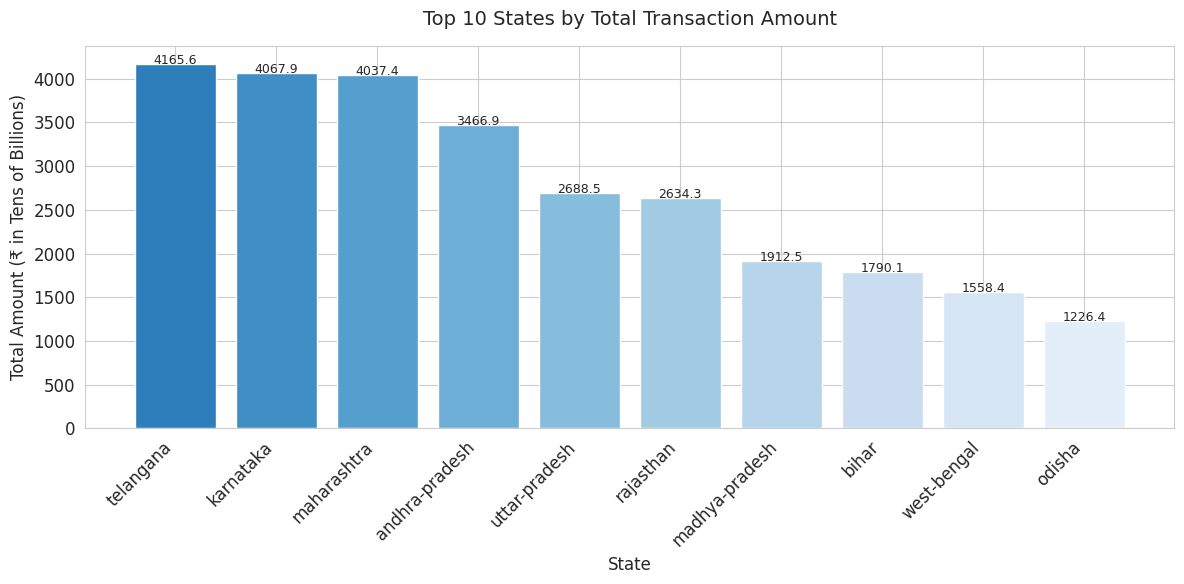

In [ ]:
# Chart - 1: Top 10 States by Total Transaction Amount (Bar Chart)
top10 = df_state_total.head(10)
fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(top10['state'], top10['total_txn_amount'] / 1e10,
              color=plt.cm.Blues_r(np.linspace(0.3, 0.9, 10)))
ax.set_title('Top 10 States by Total Transaction Amount', fontsize=14, pad=15)
ax.set_xlabel('State')
ax.set_ylabel('Total Amount (₹ in Tens of Billions)')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, top10['total_txn_amount'] / 1e10):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

#### Chart - 2

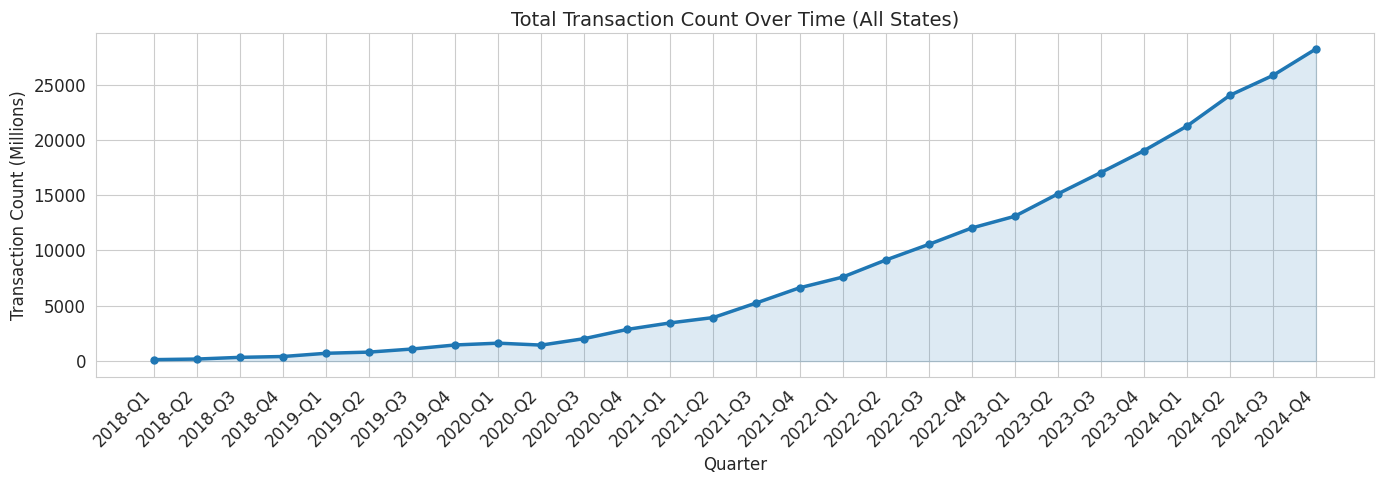

In [ ]:
# Chart - 2: Transaction Count Trend Over Time (Line Chart)
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_time_total['period'].astype(str), df_time_total['total_count'] / 1e6,
        marker='o', linewidth=2.5, color='#1f77b4', markersize=5)
ax.fill_between(df_time_total['period'].astype(str), df_time_total['total_count'] / 1e6,
                alpha=0.15, color='#1f77b4')
ax.set_title('Total Transaction Count Over Time (All States)', fontsize=14)
ax.set_xlabel('Quarter')
ax.set_ylabel('Transaction Count (Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Chart - 3

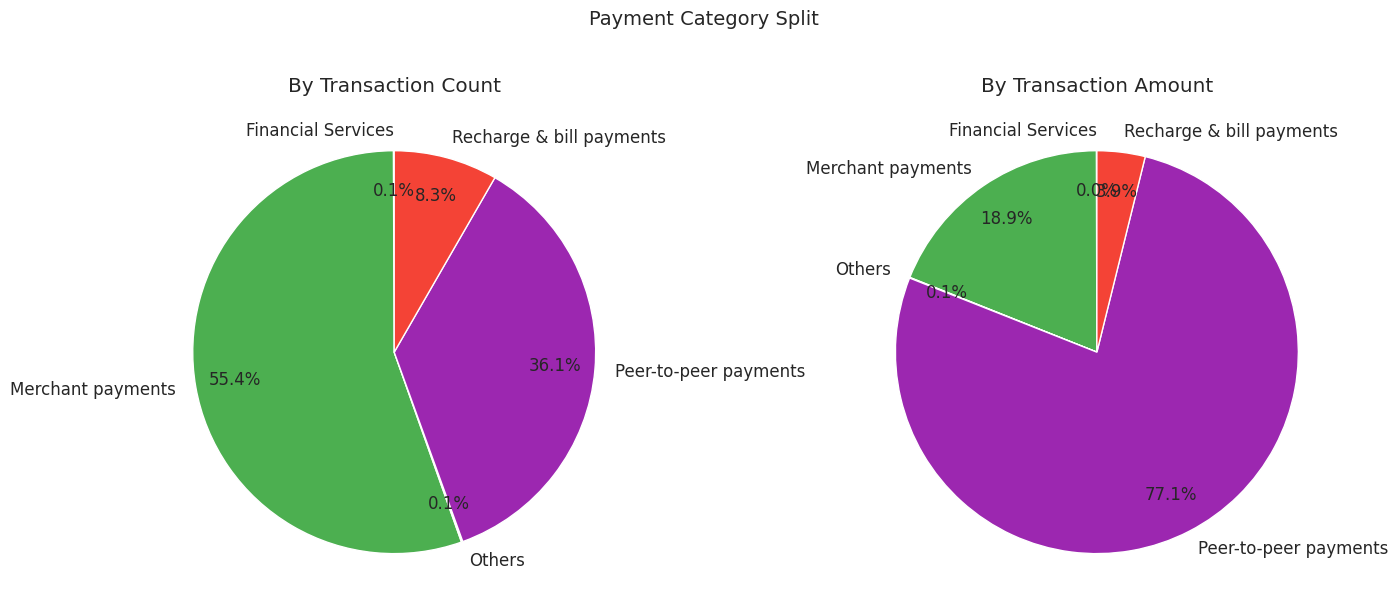

In [ ]:
# Chart - 3: Payment Category Distribution - Pie Chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
wedges, texts, autotexts = ax1.pie(df_cat_total['total_count'], labels=df_cat_total['payment_type'],
       autopct='%1.1f%%', colors=colors, pctdistance=0.8, startangle=90)
ax1.set_title('By Transaction Count')
wedges2, texts2, autotexts2 = ax2.pie(df_cat_total['total_amount'], labels=df_cat_total['payment_type'],
       autopct='%1.1f%%', colors=colors, pctdistance=0.8, startangle=90)
ax2.set_title('By Transaction Amount')
plt.suptitle('Payment Category Split', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Define years, quarters and payment_categories from actual data
years              = sorted(df_agg_txn['year'].unique().tolist())
quarters           = sorted(df_agg_txn['quarter'].unique().tolist())
payment_categories = sorted(df_agg_txn['payment_type'].unique().tolist())

print(f"Years:              {years}")
print(f"Quarters:           {quarters}")
print(f"Payment categories: {payment_categories}")

Years:              [2018, 2019, 2020, 2021, 2022, 2023, 2024]
Quarters:           [1, 2, 3, 4]
Payment categories: ['Financial Services', 'Merchant payments', 'Others', 'Peer-to-peer payments', 'Recharge & bill payments']


#### Chart - 4

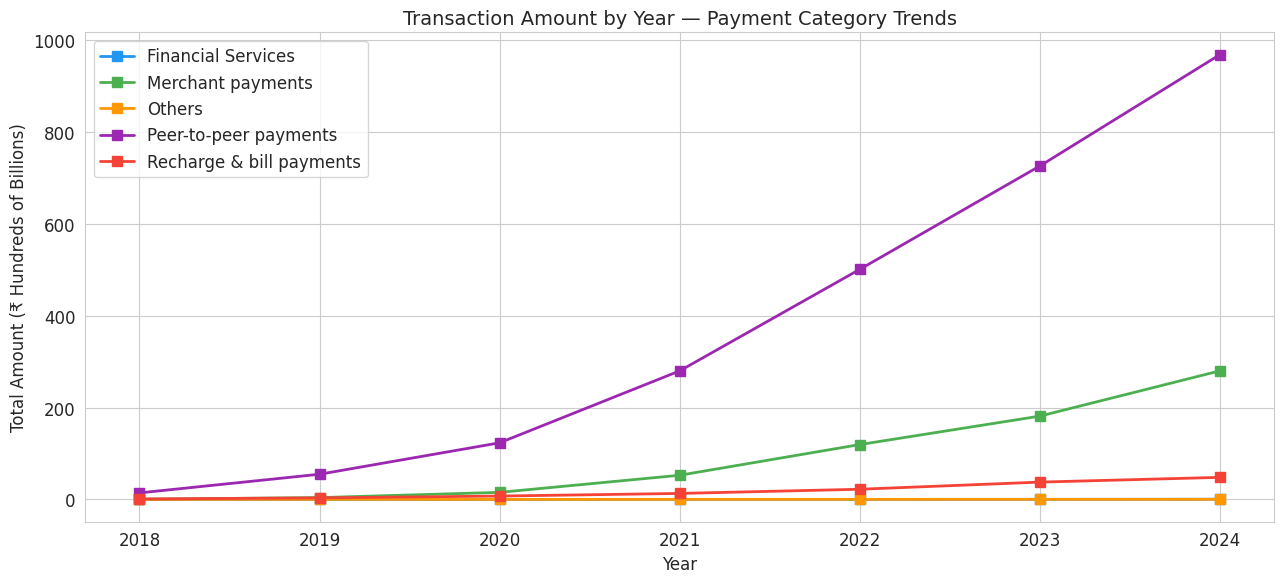

In [ ]:
# Chart - 4: Year-over-year growth by payment category
df_yoy = df_agg_txn.groupby(['year', 'payment_type'])['transaction_amount'].sum().reset_index()
fig, ax = plt.subplots(figsize=(13, 6))
for cat, color in zip(payment_categories, colors):
    sub = df_yoy[df_yoy['payment_type'] == cat].sort_values('year')
    ax.plot(sub['year'], sub['transaction_amount'] / 1e11, marker='s',
            label=cat, linewidth=2, markersize=7, color=color)
ax.set_title('Transaction Amount by Year — Payment Category Trends', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Total Amount (₹ Hundreds of Billions)')
ax.legend(loc='upper left')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

#### Chart - 5

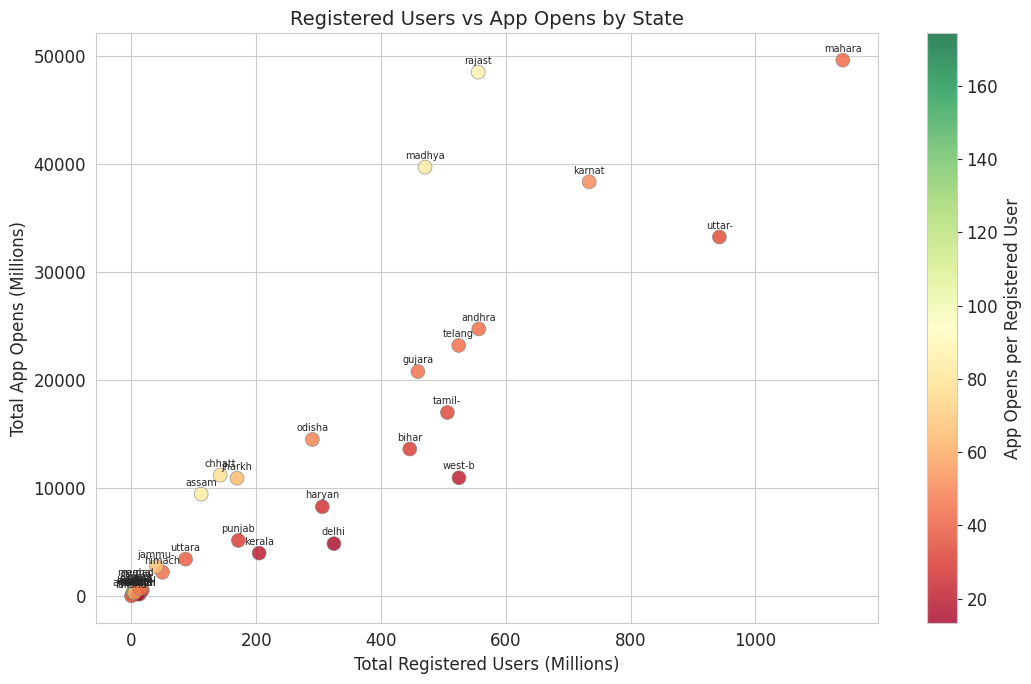

In [ ]:
# Chart - 5: Registered Users vs App Opens — Scatter plot
df_user_state = df_agg_user.groupby('state').agg(
    total_registered=('registered_users', 'sum'),
    total_opens=('app_opens', 'sum')
).reset_index()
df_user_state['opens_per_user'] = df_user_state['total_opens'] / df_user_state['total_registered']

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(df_user_state['total_registered'] / 1e6,
                     df_user_state['total_opens'] / 1e6,
                     c=df_user_state['opens_per_user'],
                     cmap='RdYlGn', s=100, alpha=0.8, edgecolors='grey', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='App Opens per Registered User')
for _, row in df_user_state.iterrows():
    ax.annotate(row['state'][:6], (row['total_registered']/1e6, row['total_opens']/1e6),
                fontsize=7, ha='center', xytext=(0, 6), textcoords='offset points')
ax.set_xlabel('Total Registered Users (Millions)')
ax.set_ylabel('Total App Opens (Millions)')
ax.set_title('Registered Users vs App Opens by State', fontsize=14)
plt.tight_layout()
plt.show()

#### Chart - 6

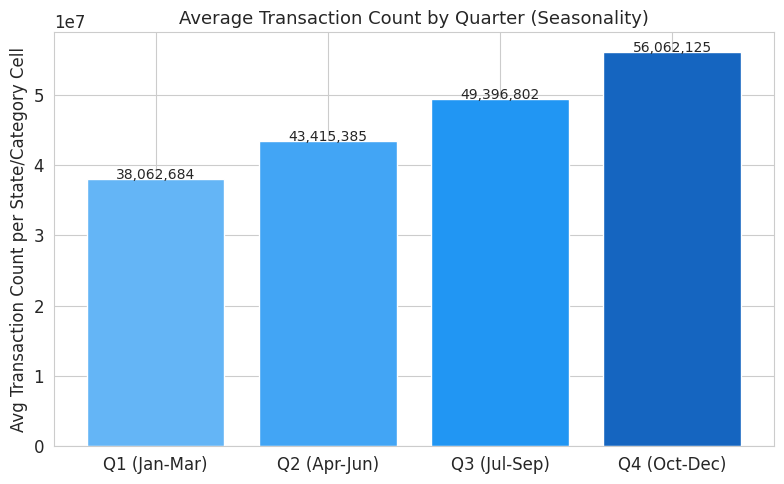

In [ ]:
# Chart - 6: Quarterly Seasonality — Average Transaction Count by Quarter
df_seasonal = df_agg_txn.groupby('quarter')['transaction_count'].mean().reset_index()
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)'],
              df_seasonal['transaction_count'],
              color=['#64B5F6', '#42A5F5', '#2196F3', '#1565C0'])
ax.set_title('Average Transaction Count by Quarter (Seasonality)', fontsize=13)
ax.set_ylabel('Avg Transaction Count per State/Category Cell')
for bar, val in zip(bars, df_seasonal['transaction_count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200, f'{val:,.0f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

#### Chart - 7

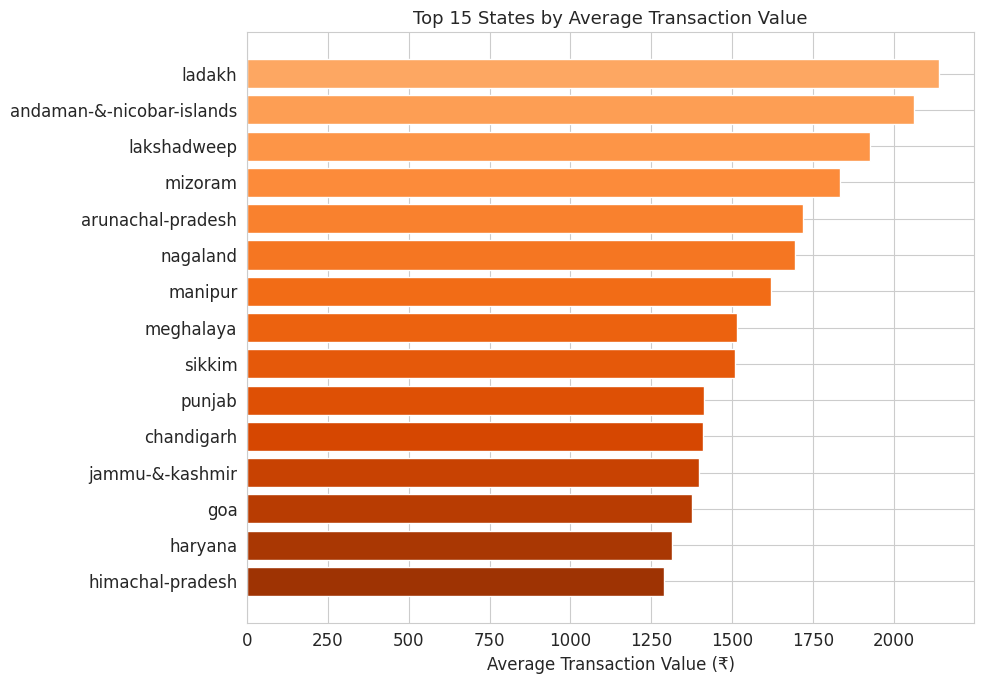

In [ ]:
# Chart - 7: State-wise Average Transaction Value (Horizontal Bar)
top15_avg = df_state_avg.head(15)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top15_avg['state'], top15_avg['avg_txn_value'],
        color=plt.cm.Oranges(np.linspace(0.4, 0.9, 15)))
ax.set_xlabel('Average Transaction Value (₹)')
ax.set_title('Top 15 States by Average Transaction Value', fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### Chart - 8

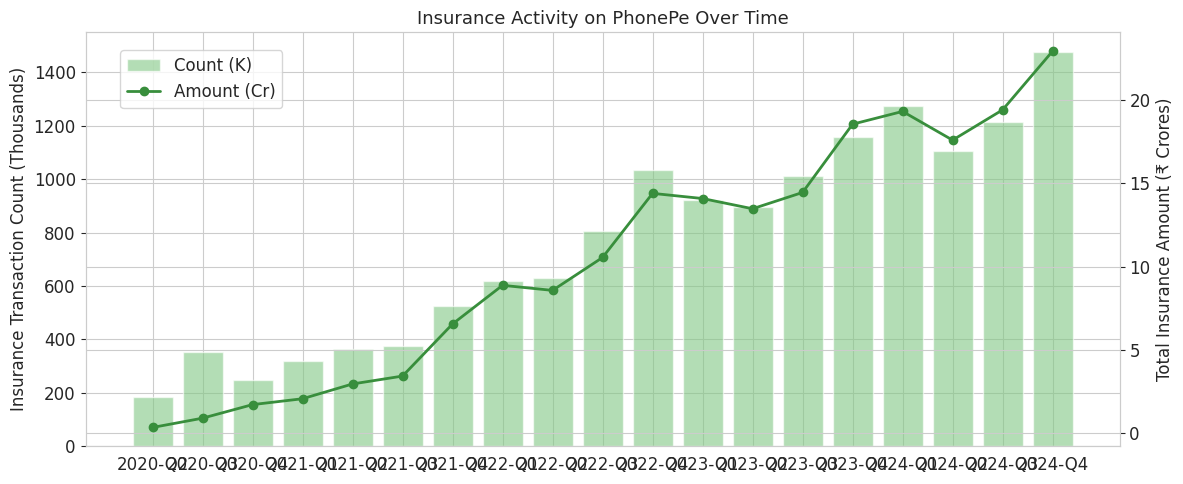

In [ ]:
# Chart - 8: Insurance Growth Over Time
df_ins_trend = df_insurance.groupby(['year', 'quarter']).agg(
    total_count=('insurance_count', 'sum'),
    total_amount=('insurance_amount', 'sum')
).reset_index()
df_ins_trend['period'] = df_ins_trend['year'].astype(str) + '-Q' + df_ins_trend['quarter'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(df_ins_trend['period'], df_ins_trend['total_count'] / 1000,
        alpha=0.6, label='Count (K)', color='#81C784')
ax2.plot(df_ins_trend['period'], df_ins_trend['total_amount'] / 1e8,
         marker='o', color='#388E3C', linewidth=2, label='Amount (Cr)')
ax1.set_ylabel('Insurance Transaction Count (Thousands)')
ax2.set_ylabel('Total Insurance Amount (₹ Crores)')
ax1.set_title('Insurance Activity on PhonePe Over Time', fontsize=13)
plt.xticks(rotation=45, ha='right')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

#### Chart - 9

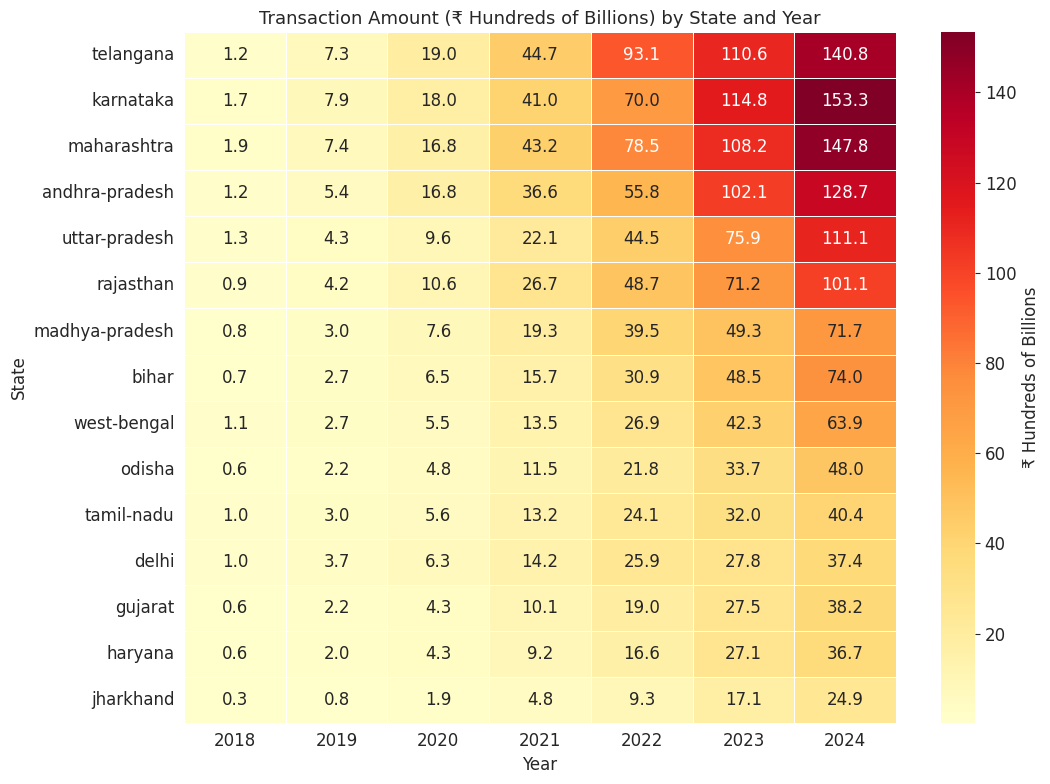

In [ ]:
# Chart - 9: Heatmap — Transaction Amount by State and Year
df_heat = df_agg_txn.groupby(['state', 'year'])['transaction_amount'].sum().unstack()
# Select top 15 states for readability
top15_states = df_state_total.head(15)['state'].tolist()
df_heat_top = df_heat.loc[top15_states]

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(df_heat_top / 1e11, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '₹ Hundreds of Billions'})
ax.set_title('Transaction Amount (₹ Hundreds of Billions) by State and Year', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('State')
plt.tight_layout()
plt.show()

#### Chart - 10

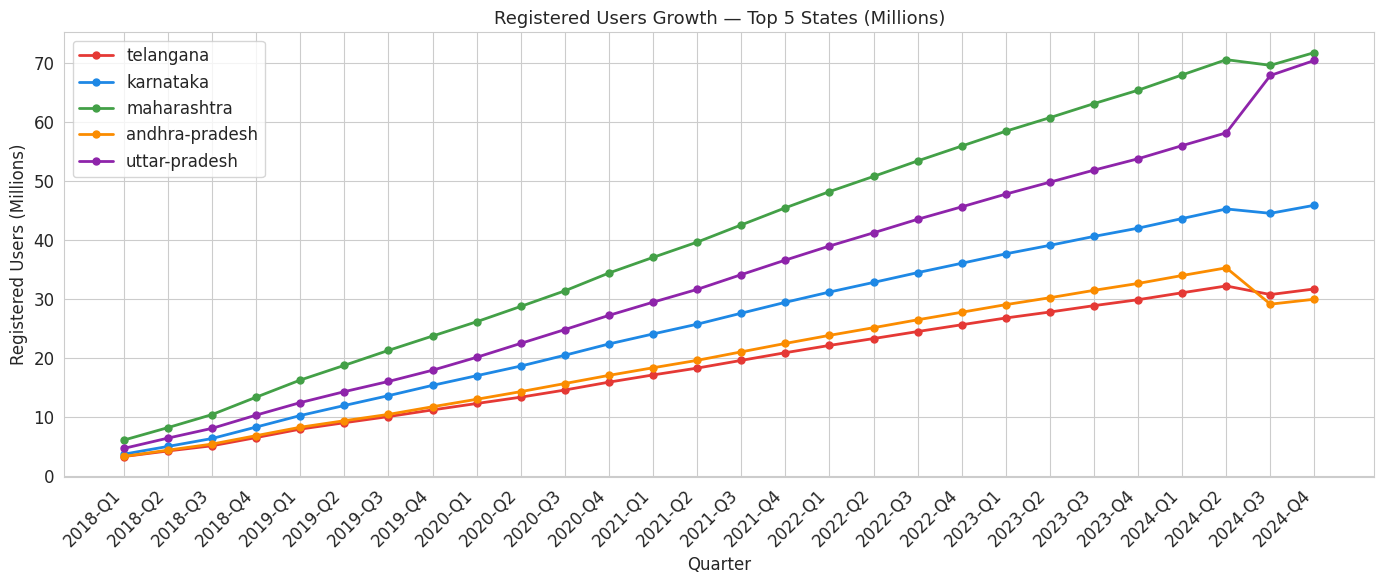

In [ ]:
# Chart - 10: Registered Users Growth — Top 5 States
top5_states = df_state_total.head(5)['state'].tolist()
df_user_top5 = df_agg_user[df_agg_user['state'].isin(top5_states)].groupby(
    ['period', 'state'])['registered_users'].sum().reset_index()
df_user_top5['period'] = pd.Categorical(df_user_top5['period'], categories=period_order, ordered=True)
df_user_top5 = df_user_top5.sort_values('period')

fig, ax = plt.subplots(figsize=(14, 6))
for state, color in zip(top5_states, ['#E53935', '#1E88E5', '#43A047', '#FB8C00', '#8E24AA']):
    sub = df_user_top5[df_user_top5['state'] == state]
    ax.plot(sub['period'].astype(str), sub['registered_users'] / 1e6,
            marker='o', label=state, linewidth=2, color=color, markersize=5)
ax.set_title('Registered Users Growth — Top 5 States (Millions)', fontsize=13)
ax.set_xlabel('Quarter')
ax.set_ylabel('Registered Users (Millions)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Chart - 11

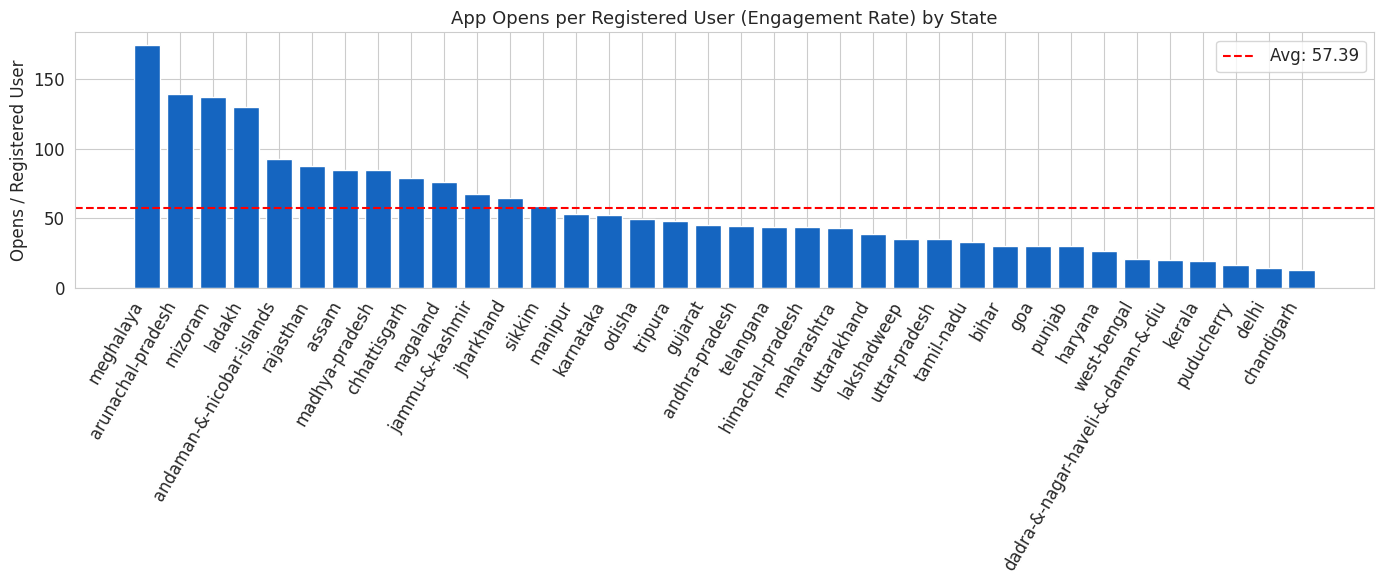

In [ ]:
# Chart - 11: App Opens per Registered User — Engagement Rate by State
df_user_state_sorted = df_user_state.sort_values('opens_per_user', ascending=False)
fig, ax = plt.subplots(figsize=(14, 6))
colors_eng = ['#1565C0' if v > 0.65 else '#90CAF9' for v in df_user_state_sorted['opens_per_user']]
ax.bar(df_user_state_sorted['state'], df_user_state_sorted['opens_per_user'], color=colors_eng)
ax.axhline(y=df_user_state_sorted['opens_per_user'].mean(), color='red', linestyle='--',
           label=f"Avg: {df_user_state_sorted['opens_per_user'].mean():.2f}")
ax.set_title('App Opens per Registered User (Engagement Rate) by State', fontsize=13)
ax.set_ylabel('Opens / Registered User')
ax.legend()
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

#### Chart - 12

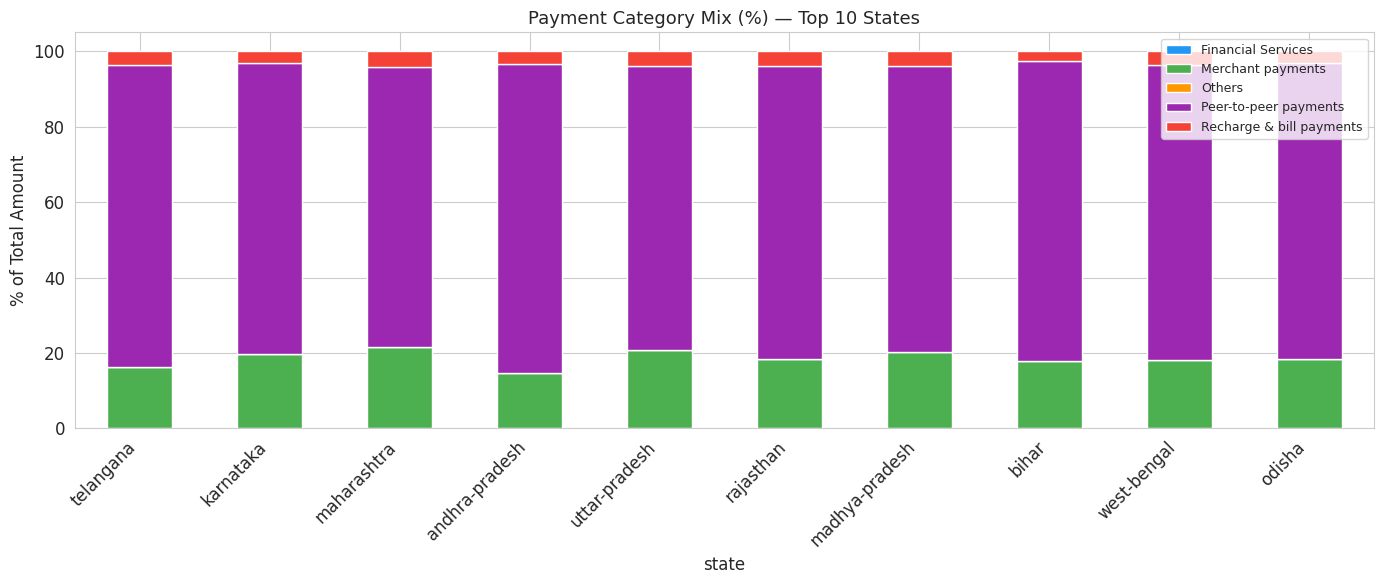

In [ ]:
# Chart - 12: Stacked Bar — Payment Category Mix by State (Top 10)
df_state_cat = df_agg_txn.groupby(['state', 'payment_type'])['transaction_amount'].sum().reset_index()
df_state_cat_pivot = df_state_cat.pivot(index='state', columns='payment_type', values='transaction_amount')
df_state_cat_pivot = df_state_cat_pivot.fillna(0)
top10_states = df_state_total.head(10)['state'].tolist()
df_plot_stacked = df_state_cat_pivot.loc[top10_states]
df_plot_pct = df_plot_stacked.div(df_plot_stacked.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
df_plot_pct.plot(kind='bar', stacked=True, ax=ax,
                 color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'])
ax.set_title('Payment Category Mix (%) — Top 10 States', fontsize=13)
ax.set_ylabel('% of Total Amount')
ax.legend(loc='upper right', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Chart - 13

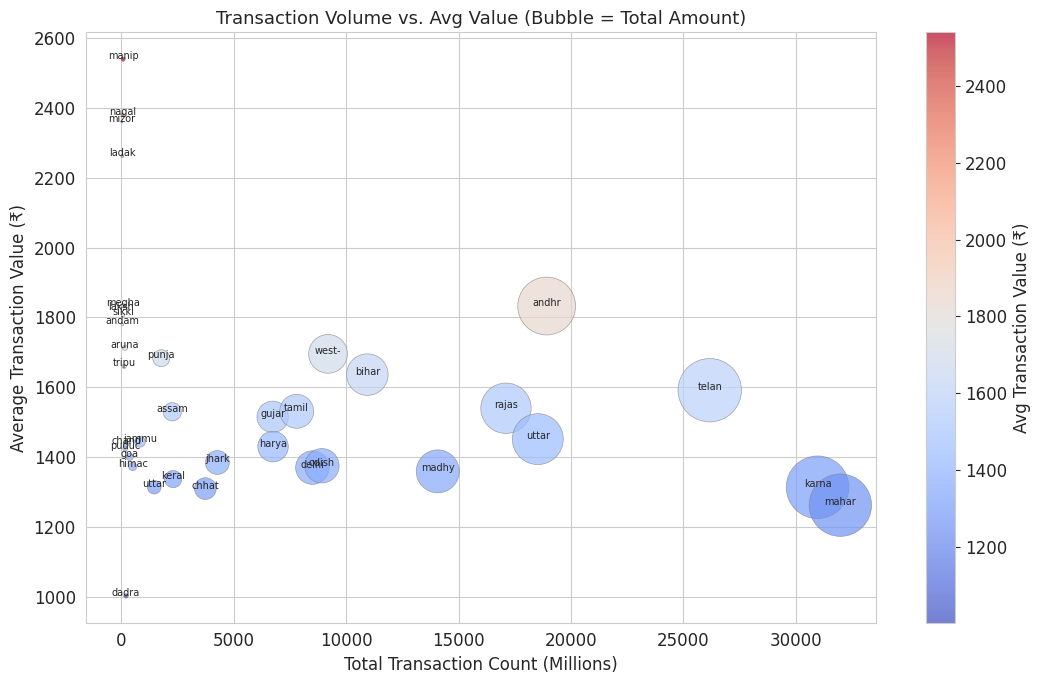

In [ ]:
# Chart - 13: Transaction Volume vs. Amount — Is There a High-Count, Low-Value Segment?
df_vol_vs_val = df_agg_txn.groupby('state').agg(
    total_count=('transaction_count', 'sum'),
    total_amount=('transaction_amount', 'sum')
).reset_index()
df_vol_vs_val['avg_value'] = df_vol_vs_val['total_amount'] / df_vol_vs_val['total_count']

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(df_vol_vs_val['total_count'] / 1e6, df_vol_vs_val['avg_value'],
                     s=df_vol_vs_val['total_amount'] / 1e12 * 50,
                     alpha=0.7, c=df_vol_vs_val['avg_value'],
                     cmap='coolwarm', edgecolors='gray', linewidth=0.5)
plt.colorbar(scatter, ax=ax, label='Avg Transaction Value (₹)')
for _, row in df_vol_vs_val.iterrows():
    ax.annotate(row['state'][:5], (row['total_count']/1e6, row['avg_value']),
                fontsize=7, ha='center')
ax.set_xlabel('Total Transaction Count (Millions)')
ax.set_ylabel('Average Transaction Value (₹)')
ax.set_title('Transaction Volume vs. Avg Value (Bubble = Total Amount)', fontsize=13)
plt.tight_layout()
plt.show()

#### Chart - 14 - Correlation Heatmap

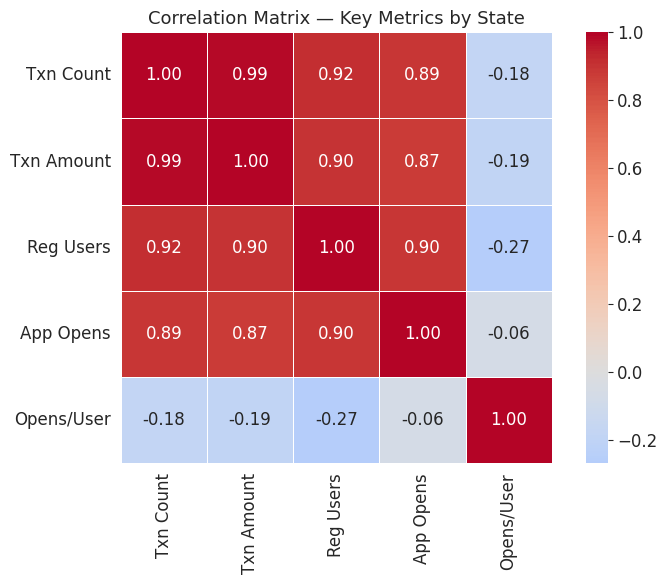

In [ ]:
# Correlation Heatmap visualization code
# Merge user and transaction data at state level
df_merge = df_state_total.merge(df_user_state[['state', 'total_registered', 'total_opens', 'opens_per_user']], on='state')
df_corr = df_merge[['total_txn_count', 'total_txn_amount', 'total_registered', 'total_opens', 'opens_per_user']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax, square=True,
            xticklabels=['Txn Count', 'Txn Amount', 'Reg Users', 'App Opens', 'Opens/User'],
            yticklabels=['Txn Count', 'Txn Amount', 'Reg Users', 'App Opens', 'Opens/User'])
ax.set_title('Correlation Matrix — Key Metrics by State', fontsize=13)
plt.tight_layout()
plt.show()

#### Chart - 15 - Pair Plot

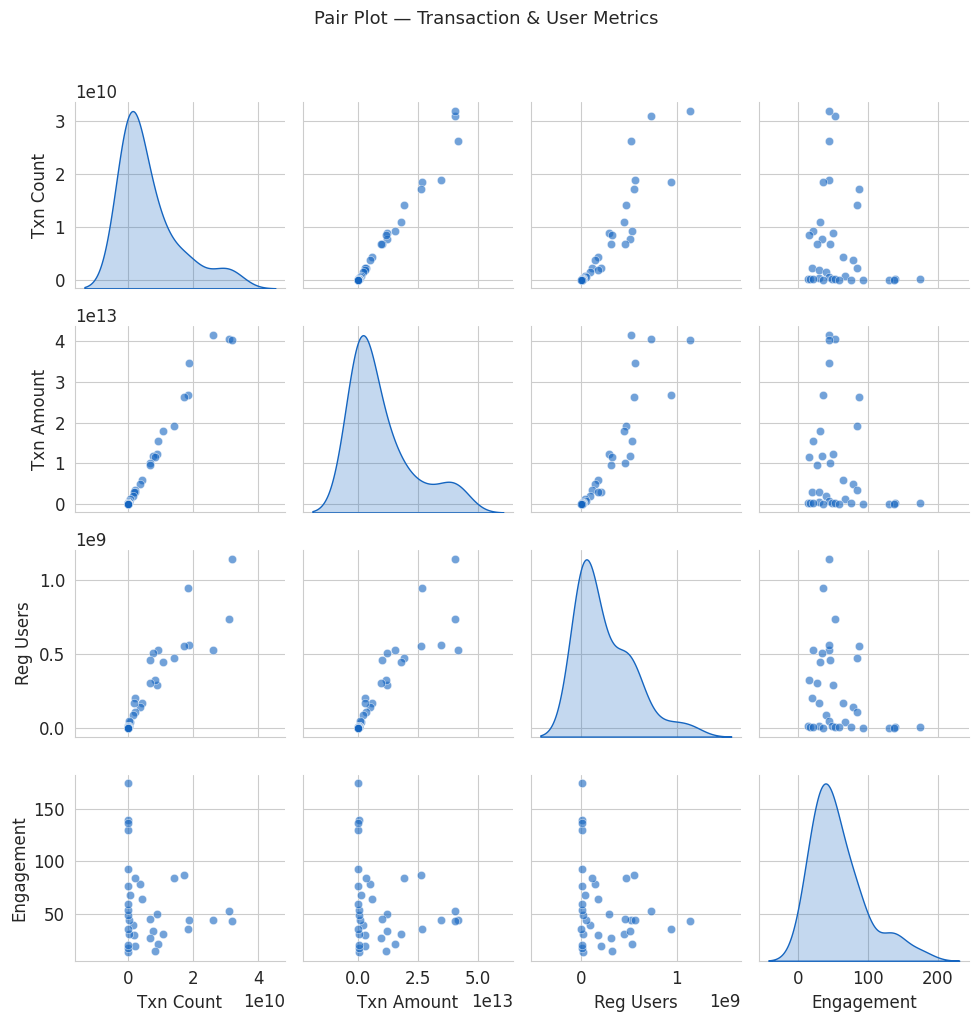

In [ ]:
# Pair Plot visualization code
import seaborn as sns
df_pair = df_merge[['total_txn_count', 'total_txn_amount', 'total_registered', 'opens_per_user']].copy()
df_pair.columns = ['Txn Count', 'Txn Amount', 'Reg Users', 'Engagement']
g = sns.pairplot(df_pair, diag_kind='kde', plot_kws={'alpha': 0.6, 'color': '#1565C0'},
                 diag_kws={'color': '#1565C0', 'fill': True})
g.fig.suptitle('Pair Plot — Transaction & User Metrics', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### Chart - 16: Insurance Top 10 States

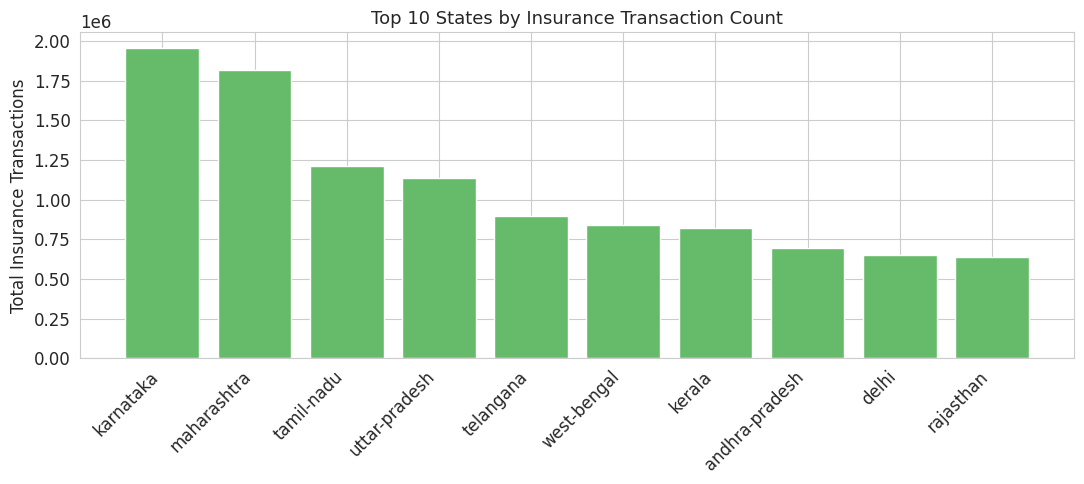

In [ ]:
# Chart 16 - Top 10 states by insurance transaction count
df_ins_state = df_insurance.groupby('state')['insurance_count'].sum().reset_index().sort_values('insurance_count', ascending=False).head(10)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df_ins_state['state'], df_ins_state['insurance_count'], color='#66BB6A')
ax.set_title('Top 10 States by Insurance Transaction Count', fontsize=13)
ax.set_ylabel('Total Insurance Transactions')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Chart - 17: YoY % Growth in Transaction Count

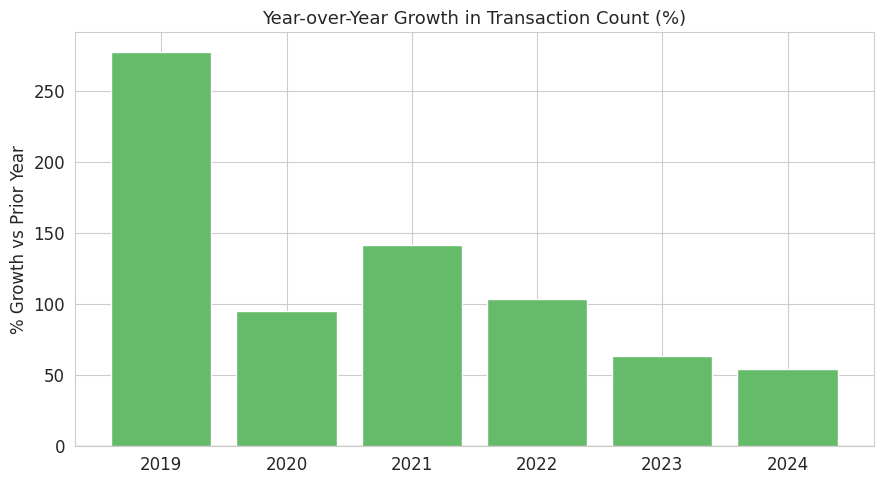

In [ ]:
# Chart 17 - Year over Year % growth in total transaction count
df_ygrowth = df_agg_txn.groupby('year')['transaction_count'].sum().reset_index()
df_ygrowth['pct_growth'] = df_ygrowth['transaction_count'].pct_change() * 100
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(df_ygrowth['year'].astype(str)[1:], df_ygrowth['pct_growth'].dropna(),
       color=['#EF5350' if v < 0 else '#66BB6A' for v in df_ygrowth['pct_growth'].dropna()])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year-over-Year Growth in Transaction Count (%)', fontsize=13)
ax.set_ylabel('% Growth vs Prior Year')
plt.tight_layout()
plt.show()

#### Chart - 18: Quarterly Average App Opens Trend

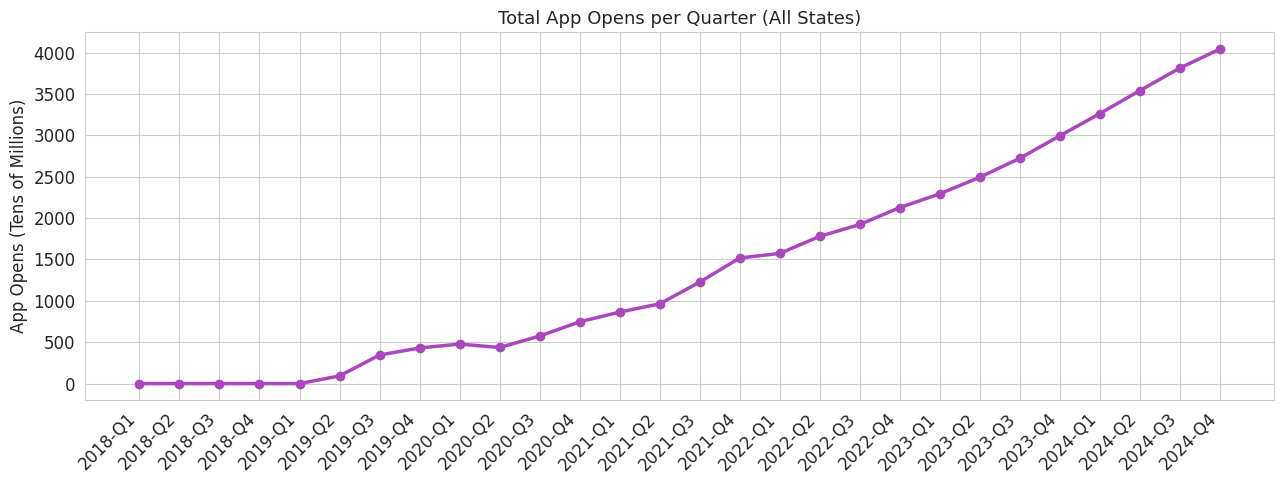

In [ ]:
# Chart 18 - App opens trend
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df_user_trend['period'].astype(str), df_user_trend['total_opens'] / 1e7,
        marker='o', color='#AB47BC', linewidth=2.5)
ax.set_title('Total App Opens per Quarter (All States)', fontsize=13)
ax.set_ylabel('App Opens (Tens of Millions)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Chart - 19: Box Plot — Transaction Amount Distribution by Payment Type

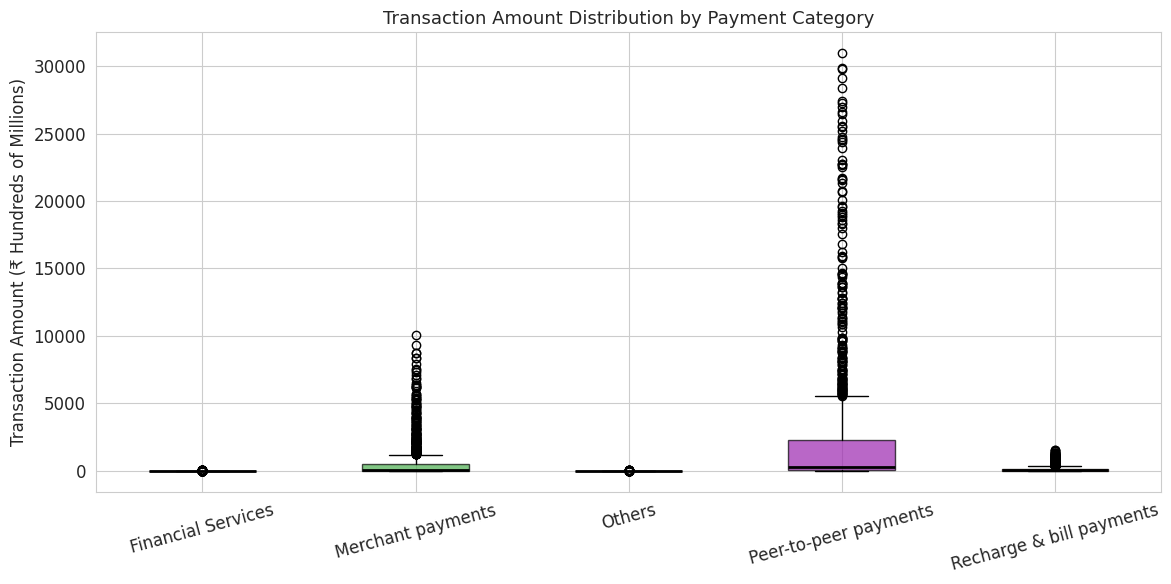

In [ ]:
# Chart 19 - Box plot of transaction amounts by category
fig, ax = plt.subplots(figsize=(12, 6))
data_by_cat = [df_agg_txn[df_agg_txn['payment_type'] == cat]['transaction_amount'] / 1e8
               for cat in payment_categories]
bp = ax.boxplot(data_by_cat, labels=payment_categories, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Transaction Amount Distribution by Payment Category', fontsize=13)
ax.set_ylabel('Transaction Amount (₹ Hundreds of Millions)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Chart - 20: Registered Users vs Insurance Penetration

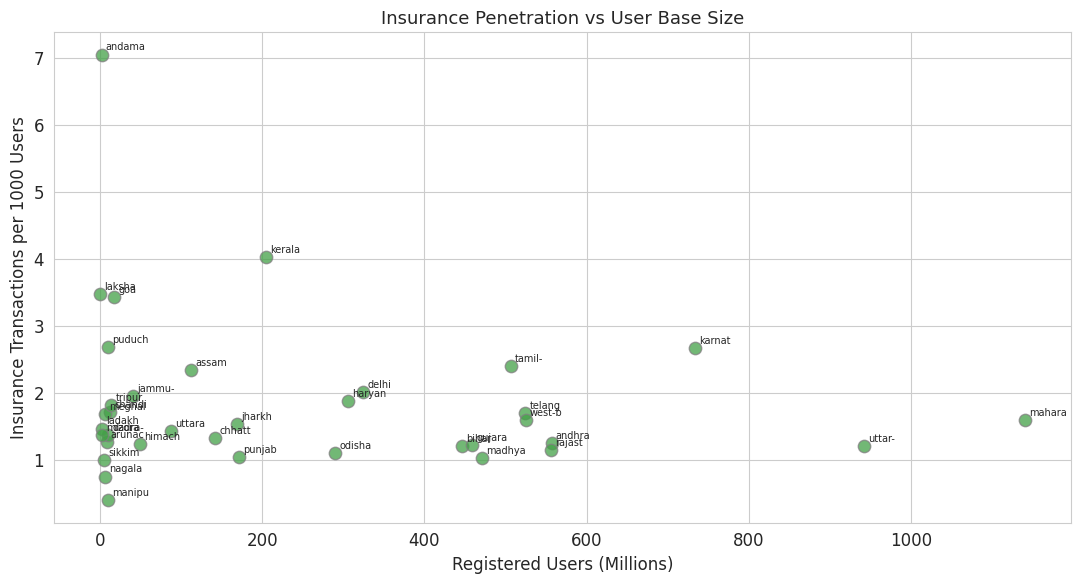

In [ ]:
# Chart 20 - Registered users vs insurance adoption (scatter)
df_ins_state_totals = df_insurance.groupby('state')['insurance_count'].sum().reset_index()
df_user_state_totals = df_agg_user.groupby('state')['registered_users'].sum().reset_index()
df_ins_vs_user = df_ins_state_totals.merge(df_user_state_totals, on='state')
df_ins_vs_user['ins_per_1000_users'] = df_ins_vs_user['insurance_count'] / df_ins_vs_user['registered_users'] * 1000

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(df_ins_vs_user['registered_users'] / 1e6, df_ins_vs_user['ins_per_1000_users'],
           s=80, alpha=0.75, c='#43A047', edgecolors='gray')
for _, row in df_ins_vs_user.iterrows():
    ax.annotate(row['state'][:6], (row['registered_users']/1e6, row['ins_per_1000_users']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')
ax.set_xlabel('Registered Users (Millions)')
ax.set_ylabel('Insurance Transactions per 1000 Users')
ax.set_title('Insurance Penetration vs User Base Size', fontsize=13)
plt.tight_layout()
plt.show()

## **5. Solution to Business Objective**

#### What do I suggest the client to achieve Business Objective


A few concrete things the data points to:

**1. Double down on merchant payments in tier-2 cities.** The category is growing faster than P2P but still underpenetrated outside metro areas. QR code expansion campaigns in smaller cities would show returns quickly given the existing user base.

**2. Targeted re-engagement in high-registration, low-engagement states** (mostly northern and eastern India). These aren't cold markets — people signed up. They just aren't using the app regularly. Regional language UI and hyperlocal merchant integrations might help.

**3. Insurance cross-sell timing.** The Q4 festive spike is when users are already active and spending. That's the window to push insurance discovery — not January when activity dips.

**4. Don't over-invest in already-saturated states.** Maharashtra and Karnataka are doing fine on their own. The marginal return from marketing spend there is lower than in Rajasthan, Odisha, or Madhya Pradesh where transaction growth is steep but absolute volumes are still low.

**5. Financial Services is the highest-ticket category** — growing fast and concentrated in affluent states. For users who already use P2P regularly, nudging them toward mutual funds or loan products (with appropriate risk disclosures) would significantly lift revenue per user.

# **Conclusion**

The PhonePe dataset tells a pretty clear story: the platform is growing everywhere, but not equally. A handful of states account for the bulk of transaction value, P2P transfers still dominate the category mix, and the southern states punch above their weight in engagement.

What I found most interesting was the insurance data. It's small right now, but the growth trajectory in 2022-2023 is steep. That's probably the category to watch over the next few years — it has the highest per-transaction value and the lowest current penetration, which is a good combination for a growth story.

The main takeaway for the business: stop optimizing for volume metrics alone. Engagement rate (opens per registered user) is a better leading indicator of monetization potential. States with high engagement and mid-level volume are the ones most likely to respond to product expansion. States with huge user counts but low engagement need retention work first.